In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.svm import SVR
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import ttest_rel
from sklearn.compose import TransformedTargetRegressor

In [27]:
df = pd.read_csv('Time Data - Sheet3.csv')

<Axes: >

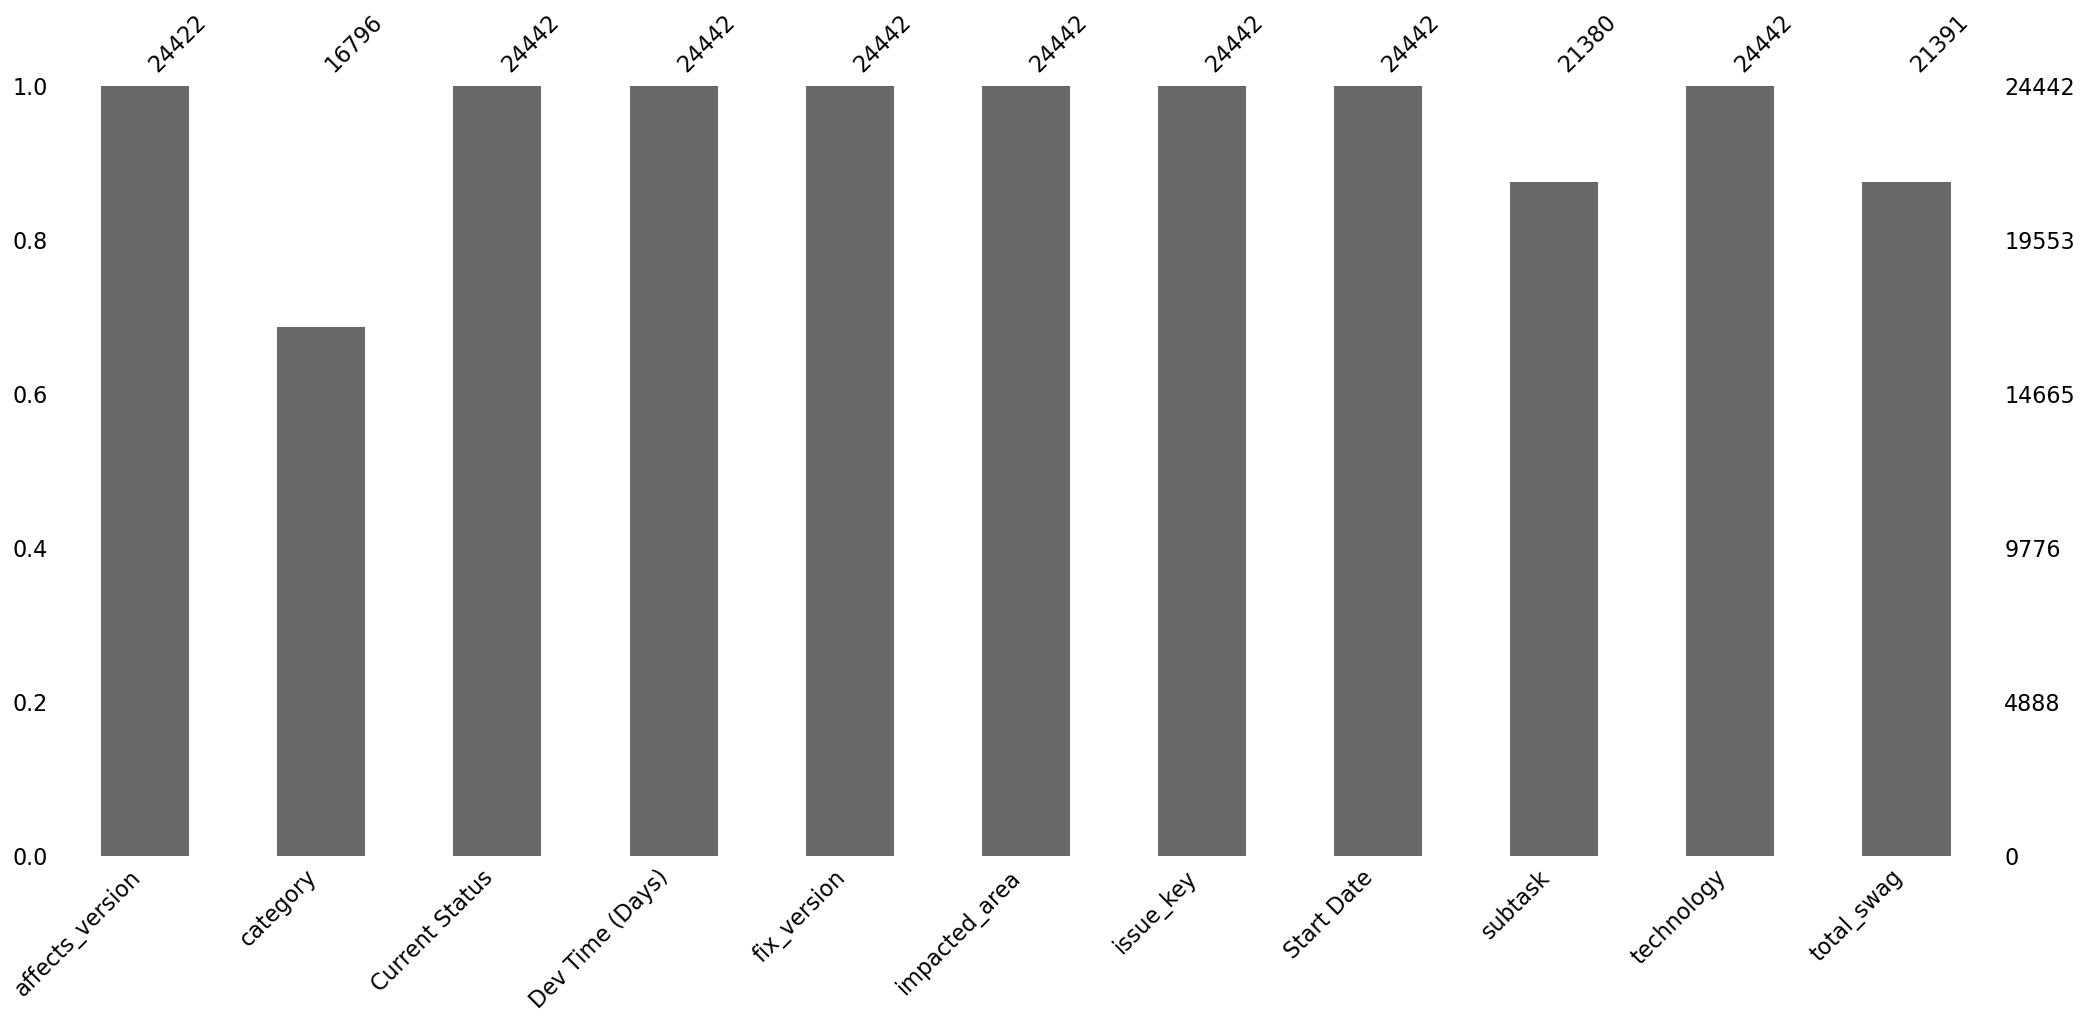

In [28]:
msno.bar(df)

<Axes: >

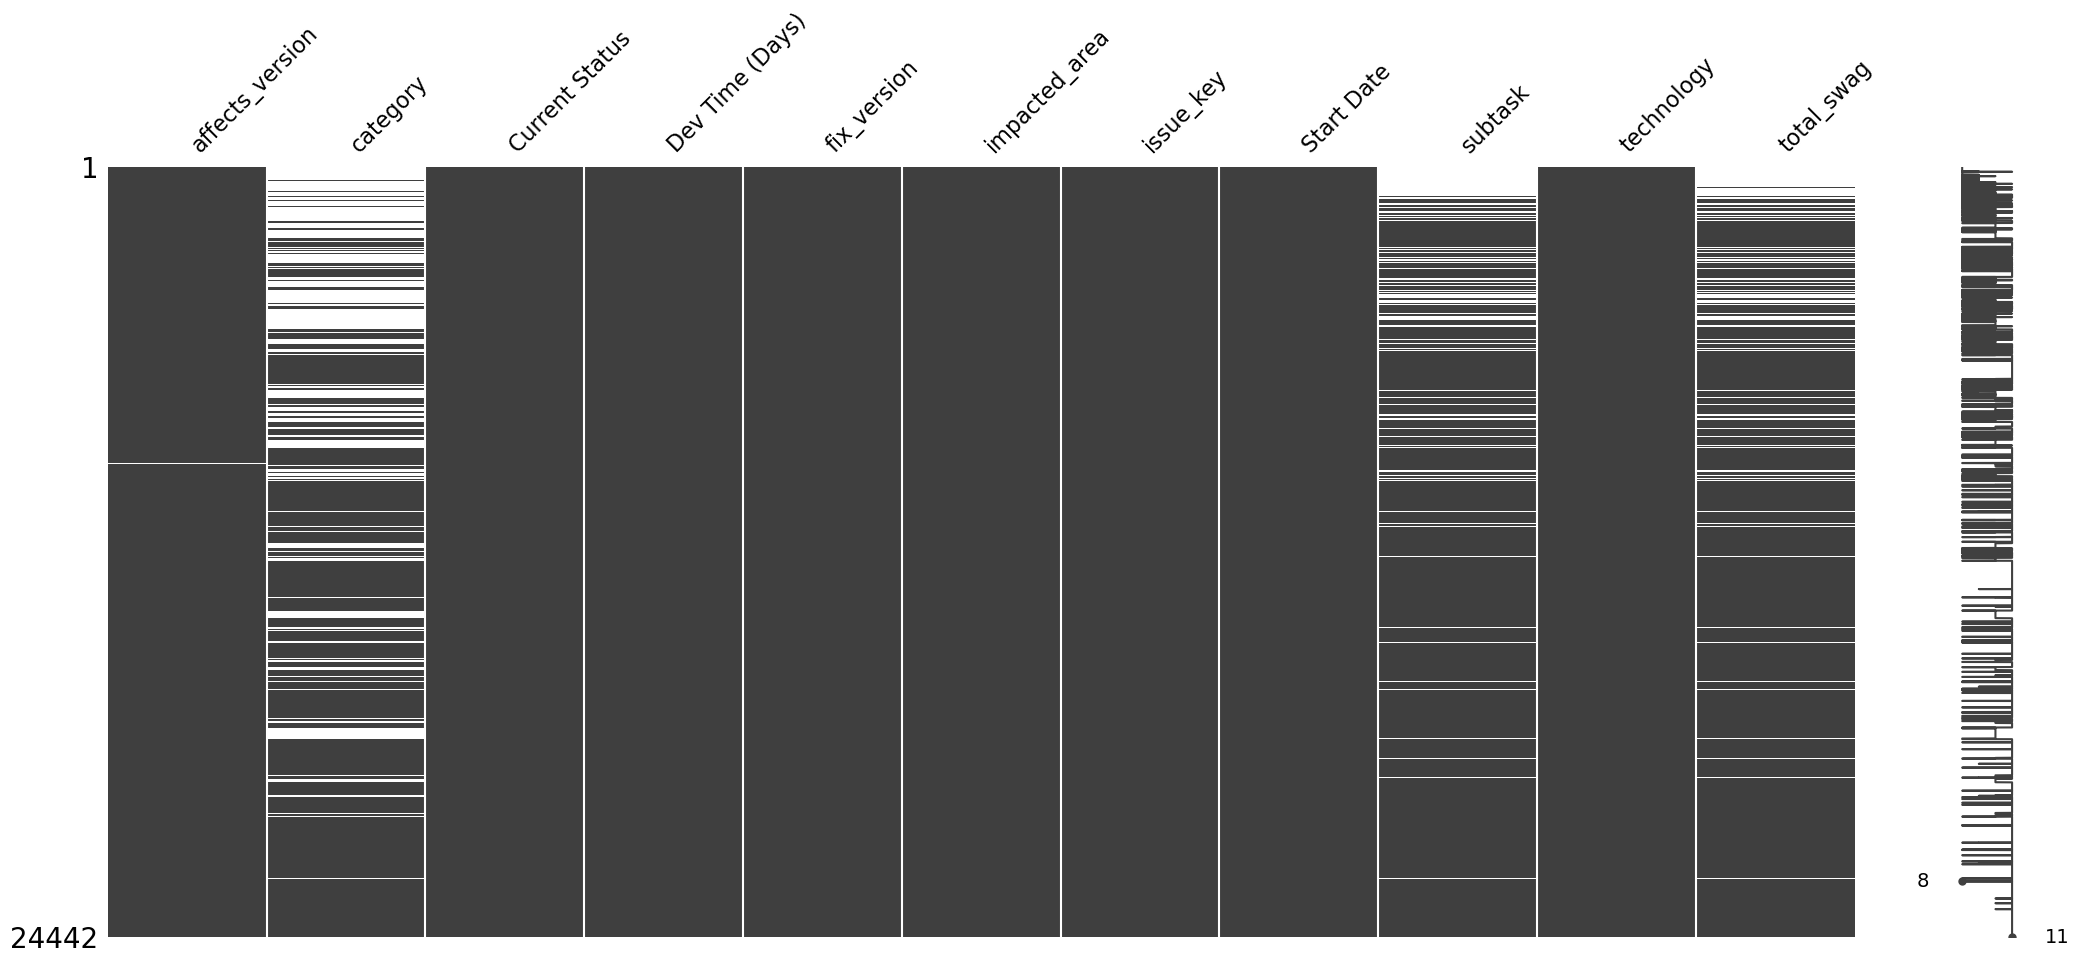

In [29]:
msno.matrix(df)

In [30]:
# Remove rows where the 'Dev Time (Days)' column is 0
df_filtered = df[df['Dev Time (Days)'] > 30]

print("Rows with 'Dev Time (Days)' equal to 0 or 1 have been removed.")

Rows with 'Dev Time (Days)' equal to 0 or 1 have been removed.


In [31]:
len(df), len(df_filtered)

(24442, 23775)

In [32]:
df_final = df_filtered.drop('subtask', axis=1)
df_final.drop_duplicates(inplace=True)

In [33]:
category_encoded = df_filtered['category'].str.strip().str.get_dummies(sep=',').astype(int)

df_encoded = pd.get_dummies(df_filtered, columns=['impacted_area', 'technology','affects_version','fix_version'], dtype=int)

df_final = pd.concat([df_encoded, category_encoded], axis=1)
df_final = df_final.drop('category', axis =1)
df_final.head(50)

,Current Status,Dev Time (Days),issue_key,Start Date,subtask,total_swag,impacted_area_(none),impacted_area_3rd Party,impacted_area_AMS,impacted_area_ASTRO Infrastructure,...,Cyber RR,Engineering,One list,PDM,Parity/Evolution,Quality,Quality-ENG,Roadmap/PCN,SLT,Security
667,Closed,31,DEVASTRO-1317,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
668,Closed,31,DEVASTRO-1321,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
669,Closed,31,DEVASTRO-1318,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
670,Closed,31,DEVASTRO-1316,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
671,Closed,31,DEVASTRO-1320,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
672,Closed,31,DEVASTRO-1713,14/09/2020 00:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
673,Closed,31,DEVASTRO-2840,19/07/2021 00:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
674,Closed,31,DEVASTRO-2842,19/07/2021 00:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
675,Closed,31,DEVASTRO-2841,19/07/2021 00:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
676,Closed,31,DEVASTRO-4950,02/05/2023 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
df_final['total_swag']

667             NaN
668             NaN
669             NaN
670             NaN
671             NaN
            ...    
24437    386,620.80
24438    386,620.80
24439    386,620.80
24440    386,620.80
24441    386,620.80
Name: total_swag, Length: 23775, dtype: object

In [35]:
df_final['Start Date'].dtype

dtype('O')

In [36]:
df_final['Start Date'] = pd.to_datetime(df_final['Start Date'], dayfirst=True)

In [37]:
df_final['Start Date'] = df_final['Start Date'].dt.strftime('%Y%m%d').astype(int)

In [38]:
df_final['Start Date']

667      20200609
668      20200609
669      20200609
670      20200609
671      20200609
           ...   
24437    20180518
24438    20180518
24439    20180518
24440    20180518
24441    20180518
Name: Start Date, Length: 23775, dtype: int64

In [39]:
df_final.head(10)
print(df_final.select_dtypes(include='object').columns.tolist())

['Current Status', 'issue_key', 'subtask', 'total_swag']


In [40]:
df_final['total_swag'] = (pd.to_numeric(df_final['total_swag'].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float64'))

In [41]:
# Correctly define your features (X) by dropping both the target and the non-numerical issue_key
X = df_final.drop(['Dev Time (Days)', 'issue_key','subtask','Current Status', 'Start Date'], axis=1)
y = df_final['Dev Time (Days)']
# Now, split the data and train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calculate the R-squared score
r2 = r2_score(y_test, predictions)
print(f"R-squared Score: {r2:.2f}")

imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.to_string(max_rows=None))

Model trained successfully!
Mean Absolute Error (MAE): 19.85
R-squared Score: 0.97
total_swag                                  5.735857e-01
fix_version_ASTRO_SR2023.3                  5.265910e-02
One list                                    4.915126e-02
Parity/Evolution                            4.062462e-02
Application services                        3.854493e-02
fix_version_ASTRO_SR2024.2                  3.469102e-02
affects_version_ASTRO_SR2023.2              2.333825e-02
affects_version_ASTRO_SR2021.2              2.282180e-02
affects_version_ASTRO_SR2021.1              1.958662e-02
Security                                    1.348213e-02
fix_version_(no version)                    1.223656e-02
affects_version_ASTRO_SR2025.2              1.199345e-02
fix_version_ASTRO_SR2025.1MR                1.000853e-02
affects_version_ASTRO_SR2022.3              9.370062e-03
fix_version_ASTRO_SR2025.1                  8.816207e-03
Quality                                     6.329253e-03
affec

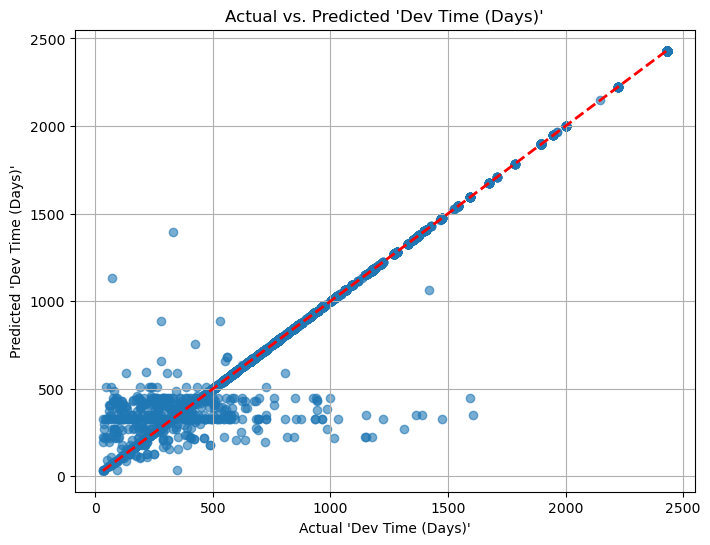

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual 'Dev Time (Days)'")
plt.ylabel("Predicted 'Dev Time (Days)'")
plt.title("Actual vs. Predicted 'Dev Time (Days)'")
plt.grid(True)
plt.savefig('predictions_vs_actual.png')

In [43]:
# Correctly define your features (X) by dropping both the target and the non-numerical issue_key
X = df_final.drop(['Dev Time (Days)', 'issue_key','subtask','Current Status', 'Start Date'], axis=1)
y = df_final['Dev Time (Days)']
# Now, split the data and train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calculate the R-squared score
r2 = r2_score(y_test, predictions)
print(f"R-squared Score: {r2:.2f}")

imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.to_string(max_rows=None))

Model trained successfully!
Mean Absolute Error (MAE): 38.54
R-squared Score: 0.97
fix_version_ASTRO_SR2024.2                  1.166586e-01
fix_version_ASTRO_SR2023.3                  1.050828e-01
Application services                        8.047008e-02
Parity/Evolution                            7.828018e-02
affects_version_ASTRO_SR2020.3              3.886958e-02
affects_version_ASTRO_SR2025.2              3.850522e-02
fix_version_ASTRO_SR2025.1MR                2.764323e-02
fix_version_ASTRO_SR2024.3                  2.674091e-02
affects_version_ASTRO_SR2021.1              2.673190e-02
total_swag                                  2.623359e-02
One list                                    2.588811e-02
fix_version_ASTRO_SR2025.1                  2.515206e-02
affects_version_ASTRO_SR2024.3              2.446792e-02
affects_version_ASTRO_SR2022.3              2.189679e-02
affects_version_ASTRO_SR2024.1              1.839984e-02
fix_version_(no version)                    1.812765e-02
affec

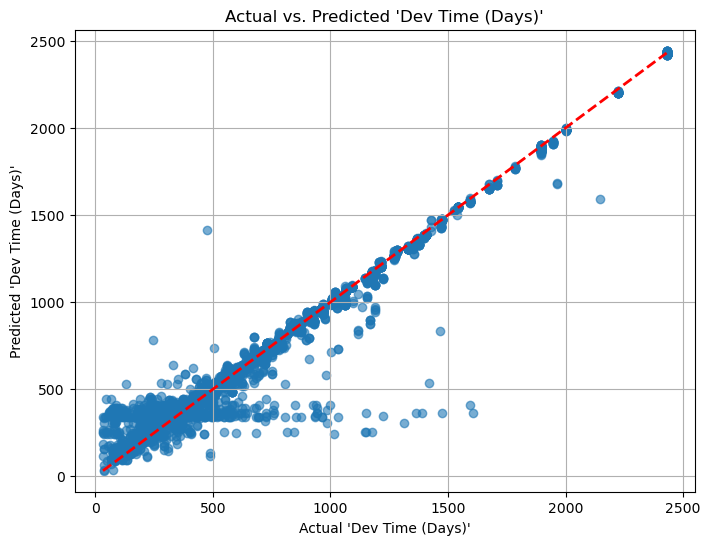

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual 'Dev Time (Days)'")
plt.ylabel("Predicted 'Dev Time (Days)'")
plt.title("Actual vs. Predicted 'Dev Time (Days)'")
plt.grid(True)
plt.savefig('predictions_vs_actual.png')

# Test Multiple Imputation Methods for total_swag

In [45]:
df = df_final.copy()
num_cols = df.select_dtypes(include='number').columns
assert 'total_swag' in num_cols, "total_swag must be numeric."
df_num = df[num_cols]

In [46]:
obs_idx = df_num['total_swag'].dropna().index
rng = np.random.default_rng(42)
val_size = max(1, int(0.2 * len(obs_idx)))
val_idx = rng.choice(obs_idx, size=val_size, replace=False)
df_test = df_num.copy()
y_true = df_test.loc[val_idx, 'total_swag'].to_numpy()
df_test.loc[val_idx, 'total_swag'] = np.nan

Bayesian Ridge (features scaled)

In [ ]:
est = make_pipeline(StandardScaler(), BayesianRidge())
m = 20
imputed_preds =[]

for seed in range(m):
    imp = IterativeImputer(estimator=est, sample_posterior = True, random_state = seed, max_iter = 100, skip_complete=True)
    imputed = imp.fit_transform(df_test)
    imputed_df = pd.DataFrame(imputed, columns = df_test.columns, index = df_test.index)
    imputed_preds.append(imputed_df.loc[val_idx, 'total_swag'].to_numpy())

imputed_preds = np.vstack(imputed_preds)
y_pred = imputed_preds.mean(axis=0)
mae = mean_absolute_error(y_true,y_pred)
rmse = mean_squared_error(y_true, y_pred)
print(f"MAE: {mae:.3f} RMSE: {rmse:.3f} Mean imputation SD: {imputed_preds.std(axis=0).mean():.3f}")

Linear Regression

In [ ]:
m = 20
imputed_preds =[]

for seed in range(m):
    imp = IterativeImputer(estimator=LinearRegression(), sample_posterior = False, random_state = seed, max_iter = 100, skip_complete=True)
    imputed = imp.fit_transform(df_test)
    imputed_df = pd.DataFrame(imputed, columns = df_test.columns, index = df_test.index)
    imputed_preds.append(imputed_df.loc[val_idx, 'total_swag'].to_numpy())

imputed_preds = np.vstack(imputed_preds)
y_pred = imputed_preds.mean(axis=0)
mae = mean_absolute_error(y_true,y_pred)
rmse = mean_squared_error(y_true, y_pred)
print(f"MAE: {mae:.3f} RMSE: {rmse:.3f} Mean imputation SD: {imputed_preds.std(axis=0).mean():.3f}")

Decision Tree

In [ ]:
m = 20
imputed_preds =[]

for seed in range(m):
    imp = IterativeImputer(estimator=DecisionTreeRegressor(random_state=seed), sample_posterior = False, random_state = seed, max_iter = 100, skip_complete=True)
    imputed = imp.fit_transform(df_test)
    imputed_df = pd.DataFrame(imputed, columns = df_test.columns, index = df_test.index)
    imputed_preds.append(imputed_df.loc[val_idx, 'total_swag'].to_numpy())

imputed_preds = np.vstack(imputed_preds)
y_pred = imputed_preds.mean(axis=0)
mae = mean_absolute_error(y_true,y_pred)
rmse = mean_squared_error(y_true, y_pred)
print(f"MAE: {mae:.3f} RMSE: {rmse:.3f} Mean imputation SD: {imputed_preds.std(axis=0).mean():.3f}")

Random Forest

In [ ]:
m = 20
imputed_preds =[]

for seed in range(m):
    imp = IterativeImputer(estimator=RandomForestRegressor(n_estimators=200, random_state=seed, n_jobs=-1), sample_posterior = False, random_state = seed, max_iter = 100, skip_complete=True)
    imputed = imp.fit_transform(df_test)
    imputed_df = pd.DataFrame(imputed, columns = df_test.columns, index = df_test.index)
    imputed_preds.append(imputed_df.loc[val_idx, 'total_swag'].to_numpy())

imputed_preds = np.vstack(imputed_preds)
y_pred = imputed_preds.mean(axis=0)
mae = mean_absolute_error(y_true,y_pred)
rmse = mean_squared_error(y_true, y_pred)
print(f"MAE: {mae:.3f} RMSE: {rmse:.3f} Mean imputation SD: {imputed_preds.std(axis=0).mean():.3f}")

Extra Trees

In [ ]:
m = 20
imputed_preds =[]

for seed in range(m):
    imp = IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=200, random_state=seed, n_jobs=-1), sample_posterior = False, random_state = seed, max_iter = 100, skip_complete=True)
    imputed = imp.fit_transform(df_test)
    imputed_df = pd.DataFrame(imputed, columns = df_test.columns, index = df_test.index)
    imputed_preds.append(imputed_df.loc[val_idx, 'total_swag'].to_numpy())

imputed_preds = np.vstack(imputed_preds)
y_pred = imputed_preds.mean(axis=0)
mae = mean_absolute_error(y_true,y_pred)
rmse = mean_squared_error(y_true, y_pred)
print(f"MAE: {mae:.3f} RMSE: {rmse:.3f} Mean imputation SD: {imputed_preds.std(axis=0).mean():.3f}")

Gradient boosting

In [ ]:
m = 20
imputed_preds =[]

for seed in range(m):
    imp = IterativeImputer(estimator=GradientBoostingRegressor(random_state=seed), sample_posterior = False, random_state = seed, max_iter = 100, skip_complete=True)
    imputed = imp.fit_transform(df_test)
    imputed_df = pd.DataFrame(imputed, columns = df_test.columns, index = df_test.index)
    imputed_preds.append(imputed_df.loc[val_idx, 'total_swag'].to_numpy())

imputed_preds = np.vstack(imputed_preds)
y_pred = imputed_preds.mean(axis=0)
mae = mean_absolute_error(y_true,y_pred)
rmse = mean_squared_error(y_true, y_pred)
print(f"MAE: {mae:.3f} RMSE: {rmse:.3f} Mean imputation SD: {imputed_preds.std(axis=0).mean():.3f}")

K Neighbours

In [ ]:
m = 20
imputed_preds =[]

for seed in range(m):
    imp = IterativeImputer(estimator=KNeighborsRegressor(n_neighbors=5), sample_posterior = False, random_state = seed, max_iter = 100, skip_complete=True)
    imputed = imp.fit_transform(df_test)
    imputed_df = pd.DataFrame(imputed, columns = df_test.columns, index = df_test.index)
    imputed_preds.append(imputed_df.loc[val_idx, 'total_swag'].to_numpy())

imputed_preds = np.vstack(imputed_preds)
y_pred = imputed_preds.mean(axis=0)
mae = mean_absolute_error(y_true,y_pred)
rmse = mean_squared_error(y_true, y_pred)
print(f"MAE: {mae:.3f} RMSE: {rmse:.3f} Mean imputation SD: {imputed_preds.std(axis=0).mean():.3f}")

Choose random forest:

In [ ]:
df_impute = df_imputation.copy()
missing_idx = df_impute.index[df_impute['total_swag'].isna()]
if len(missing_idx)>0:
    agg = np.zeros(len(missing_idx))
    for seed in range(100, 100 +m):
        imp = IterativeImputer(estimator=RandomForestRegressor(n_estimators=200, random_state=seed, n_jobs=-1), sample_posterior = False, random_state = seed, max_iter = 100, skip_complete=True)
        imputed = imp.fit_transform(df_impute)
        agg += imputed_df.loc[missing_idx, 'total_swag'].to_numpy()
        df.loc[missing_idx, 'total_swag'] = agg / m

df_imputed = df

In [ ]:

X = df_imputed.drop(['Dev Time (Days)', 'issue_key','subtask','Current Status', 'Start Date'], axis=1)
y = df_imputed['Dev Time (Days)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_imputed = XGBRegressor(random_state=42)
model_imputed.fit(X_train, y_train)

print("Model trained successfully!")
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calculate the R-squared score
r2 = r2_score(y_test, predictions)
print(f"R-squared Score: {r2:.2f}")


In [ ]:
X_a = df_final.drop(['Dev Time (Days)','issue_key','subtask','Current Status','Start Date'], axis=1)
X_b = df_imputed.drop(['Dev Time (Days)','issue_key','subtask','Current Status','Start Date'], axis=1)
y = df_final['Dev Time (Days)']
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_a = [] 
r2_b = []
for tr, te in kf.split(X_a):
    mA = XGBRegressor(random_state=42).fit(X_a.iloc[tr], y.iloc[tr])
    mB = XGBRegressor(random_state=42).fit(X_b.iloc[tr], y.iloc[tr])
    pA = mA.predict(X_a.iloc[te]); pB = mB.predict(X_b.iloc[te])
    r2_a.append(r2_score(y.iloc[te], pA))
    r2_b.append(r2_score(y.iloc[te], pB))
r2_a, r2_b = np.array(r2_a), np.array(r2_b)
t, p = ttest_rel(r2_b, r2_a)
print(f"R^2 no-impute: {r2_a.mean():.3f} imputed: {r2_b.mean():.3f} diff: {(r2_b-r2_a).mean():.3f} t={t:.2f} p={p:.3f}")

In [ ]:
df_imputed.to_csv('imputed_data.csv', index=False)